





---
<h1 style="text-align: center;">Retail Store Demand Forecasting</h1>

---

## Final Project Report - Team 3
- [Jagdish Mane](https://www.linkedin.com/in/jagdish-mane/)
- [Sachine Shukla](https://www.linkedin.com/in/sks336/)
- [Hanmant Kattimani](https://www.linkedin.com/in/hanmant-kattimani-b8323741/)

Master of Science in Applied Artificial Intelligence, University of SanDiego.<br>


**Project Title**     : Retail Store Demand Forecasting<br>
**Course**    : Probability and Statistics for Artificial Intelligence<br>
**Instructor**: Azka<br>
**Date**      : 22/06/2025<br>





---
## Table of Contents
---
| S.No | Topic                         | Description                                                                                          |
|------|--------------------------------------|------------------------------------------------------------------------------------------------------|
| 1    | [Introduction](#1.Introduction) | Define the main goals and objectives of the project.                                                 |
| 2    | [Dataset Overview](#2.Dataset-Overview) | Review the [dataset](https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting) from Kaggle.com. |
| 3    | [Data Cleaning and Preparation](#3.Data-Cleaning-and-Preparation) | Prepare and clean the dataset for further analysis and modeling.                                     |
| 4    | [Exploratory Data Analysis](#4.Exploratory-Data-Analysis)      | Perform statistical analysis and visualization on the dataset.                                       |
| 5    | [Model Selection](#5.Model-Selection)  | Select appropriate machine learning models for the project.                                          |
| 6    | [Model Analysis](#6.Model-Analysis) | Train and test the selected model(s) and evaluate performance.                                       |
| 7    | [Conclusion](#7.Conclusion)            | Summarize the findings and insights from the project.                                                |
| 8    | [Appendix](#8.Appendix)                | Include supplementary material, such as code snippets or additional details.                         |
| 9    | [References](#9.References)      | List the contributors to the project.                                                                |

---

## 1.Introduction
---

This project focuses on analyzing and forecasting product demand in retail stores using historical sales data. The goal is to uncover patterns in past sales and build predictive models that can accurately estimate future demand. These insights will enable data-driven decision-making to optimize inventory management and improve overall store operations.

### Background & Importance:

Accurate demand forecasting plays a vital role in the retail sector to ensure that inventory levels are neither excessive nor insufficient. Poor forecasting can lead to:

 - Overstocking, resulting in unnecessary storage costs and potential product wastage.
 - Inefficient resource allocation, affecting operational efficiency.
 - Stockouts, where insufficient inventory leads to lost sales and reduced customer satisfaction.

By accurately forecasting product demand, retailers can:
 - Optimize inventory management.
 - Minimize stockouts and overstocking.
 - Enhance operational efficiency across the retail network.
 - Ultimately drive increased sales, improved customer satisfaction, and higher profit margins.

### Objectives:

- To develop a predictive regression model using XGBoost that forecasts product demand for retail stores based on historical sales and operational data. 
- The goal is to reduce stockouts and overstocking, ensuring efficient inventory management and smooth supply chain operations.

---

## 2.Dataset Overview
---

  In this section, we provide a comprehensive exploration and description of the dataset utilized for this project, outlining its structure, features, and contents. The dataset, obtained from Kaggle, is titled: *Zhenzuo Zhu. (2025). Retail Store Inventory and Demand Forecasting [Data set]. Kaggle.* A local copy of the dataset has been downloaded and stored in the project repository under the ./dataset/ directory.

### 2.1 <u>Load the dataset</u>

In [7]:
import pandas as pd
sales_df = pd.read_csv('./dataset/sales_data.csv')

### 2.2 Dataset summary
To gain an initial understanding of the dataset structure and contents, we display the first few records using the **head()** function from the pandas library, which provides a preview of all features (columns) and their respective values.

In [9]:
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Prevent line wrapping
pd.set_option('display.expand_frame_repr', False)
sales_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


Next, we perform a statistical summary of the dataset using the **describe()** function from the pandas library. This provides key descriptive statistics for each numerical feature, including count, mean, standard deviation, minimum, maximum, and quartile values (25%, 50%, and 75%). These metrics offer insights into the distribution, central tendency, and variability of the data.

In [11]:
sales_df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


To understand the dataset’s structure, we utilize the **info()** function, which provides a concise summary including the number of entries, column names, data types, and the count of non-null values. This is useful for identifying data types and detecting missing values that may require preprocessing.

In [13]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

**Key Observations:**

For above two tables, listed are the sum of the key obervations on the dataset. 
 - **Total number of observations(Rows):**  76,000 records. 
 - **Total number of features:** 16
 - **Data Types:** Few features are Categorical variables and few are numerical variables. 
 - **Categorical Variables:**  Date, Store ID, Product ID, Category, Region, Weather Condition, Seasonality, Epidemic, Promotion.
 - **Quantative Variables:** Inventory Level, Units Sold, Units Ordered, Price, Discount, Competitor Pricing, Demand.
 - **Demand Feature**: In this project, the target variable is **Demand**, and it varies from  4 to 430. Demand mean = 104, with standard deviation of 46.96.

**Feature Overview**

| Feature Name         | Type               | Description                                                                 |
|----------------------|--------------------|-----------------------------------------------------------------------------|
| Date                 | Categorical        | Transaction date (760 unique days, suggests ~2 years of daily data)         |
| Store ID             | Categorical        | Unique identifier for each of the 5 stores                                  |
| Product ID           | Categorical        | Unique identifier for each of the 20 products                               |
| Category             | Categorical        | Product category (e.g., Electronics, Clothing, Groceries) - 5 unique values |
| Region               | Categorical        | Geographical region of the store (North, South, East, West - 4 regions)     |
| Inventory Level      | Numerical (int)    | Units of inventory available in store                                       |
| Units Sold           | Numerical (int)    | Number of units sold on that particular date                                |
| Units Ordered        | Numerical (int)    | Number of units ordered for replenishment                                   |
| Price                | Numerical (float)  | Selling price of the product                                                |
| Discount             | Numerical (int)    | Discount applied on the product                                             |
| Weather Condition    | Categorical        | Weather on the day (Snowy, Sunny, Cloudy, Rainy - 4 types)                  |
| Promotion            | Numerical (int)    | Promotion indicator (1 = active, 0 = no promotion)                          |
| Competitor Pricing   | Numerical (float)  | Competitor's price for a comparable product                                 |
| Seasonality          | Categorical        | Season of the year (Winter, Summer, Spring, Fall - 4 values)                |
| Epidemic             | Numerical (int)    | Binary flag indicating epidemic conditions (1 = epidemic, 0 = normal)       |
| Demand               | Numerical (int)    | Target variable - actual demand for the product on that day                 |


---

## 3.Data Cleaning and Preparation
---

In this section, we will load the dataset, examine its structure, and perform any necessary cleaning or adjustments to ensure the data is suitable for analysis.

From the `sales_df.describe()` output we observer the categorical features like Store ID, Product ID, Category, Region, Weather Condition, etc were removed. This is because pandas library will only process numberic features. So handle the categorical data we should encode the data.

Using this output, We can answer the questions related to the dataset. 
- What are the different data types ?
- Are there any missing observations ie row values are empty ?
- Can we drop some irrelevaent features ?
- Is any data conversion requeired ?

### 3.1 Data Types:
The **sales_df.info()** output shows there are mixed Data Types. As discussed in Section 1.2.4 of Foundations of Statistics for Data Scientists (Agresti & Kateri, 2021), variables can be classified as either quantitative(numerical) or categorical
  - 7 numerical columns **(int64, float64)** — suitable for statistical modeling.
  - 7 categorical columns **(object)** — Need encoding (Label/One-Hot encoding) for machine learning models.
  - Column **0** is **Date** but the data type is object, it should be converted.

### 3.2 Handling missing data: 

The **sales_df.info()** output shows there are no missing values. All the columns have 76,000 non-null values. 
We can also use pandas **isnull()** function to check number of missing values in the dataset for each columne. 

In [18]:
sales_df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

There are **no missing values** in this DataFrame.
However, if there were **missing or null values**, they can be handled in various ways depending on the situation. Some common methods include:

- Dropping missing data — removing rows or columns containing null values.
- Filling missing data based on data type:
- For numerical data: Replace missing values with the mean, median, or mode.
- For categorical data: Replace missing values with the mode (the most frequent category).
- Forward fill or backward fill — propagate values from previous or next observations.
- Interpolation — estimate missing values based on surrounding data points.

### 3.3 Drop irrelevant columns. 
- Few of the columns like **Store ID** and **Product ID** may not contirbute to prediction. So we drop these columns.
- Also columns like **Units Sold** and **Units Ordered** is directly depends on the demand and vice versa.


In [21]:
## Dropping Irrelevant Columns
drop_cols = ['Store ID', 'Product ID', 'Units Sold', 'Units Ordered']  # Irrelevant or data leakage
sales_df.drop(columns=drop_cols, inplace=True)
sales_df.head()

,Date,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,Electronics,North,195,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,Clothing,North,117,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,Clothing,North,247,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,Electronics,North,139,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,Groceries,North,152,54.41,0,Snowy,0,51.63,Winter,0,59


### 3.4 Encoding the categorical features:
The categorical features are not suitable for statestical analysis. To handle the categorical data, we hot-encode the categorical data.

In [23]:
## Encoding the Categorical Features:
cat_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']
sales_df = pd.get_dummies(sales_df, columns=cat_features, drop_first=True)
sales_df.head().T  ## Display each column as row for better visibility in the report.

,0,1,2,3,4
Date,2022-01-01,2022-01-01,2022-01-01,2022-01-01,2022-01-01
Inventory Level,195,117,247,139,152
Price,72.72,80.16,62.94,87.63,54.41
Discount,5,15,10,10,0
Promotion,0,1,1,0,0
Competitor Pricing,85.73,92.02,60.08,85.19,51.63
Epidemic,0,0,0,0,0
Demand,115,229,157,52,59
Category_Electronics,True,False,False,True,False
Category_Furniture,False,False,False,False,False


### 3.5 Data Convertion:

The **Data** column is of type "object", it should be converted to time-series data.

In [25]:
if 'Date' in sales_df.columns:
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     76000 non-null  datetime64[ns]
 1   Inventory Level          76000 non-null  int64         
 2   Price                    76000 non-null  float64       
 3   Discount                 76000 non-null  int64         
 4   Promotion                76000 non-null  int64         
 5   Competitor Pricing       76000 non-null  float64       
 6   Epidemic                 76000 non-null  int64         
 7   Demand                   76000 non-null  int64         
 8   Category_Electronics     76000 non-null  bool          
 9   Category_Furniture       76000 non-null  bool          
 10  Category_Groceries       76000 non-null  bool          
 11  Category_Toys            76000 non-null  bool          
 12  Region_North             76000 n

In [26]:
sales_df.head().T  ## Display each column as row for better visibility in the report.

,0,1,2,3,4
Date,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00,2022-01-01 00:00:00
Inventory Level,195,117,247,139,152
Price,72.72,80.16,62.94,87.63,54.41
Discount,5,15,10,10,0
Promotion,0,1,1,0,0
Competitor Pricing,85.73,92.02,60.08,85.19,51.63
Epidemic,0,0,0,0,0
Demand,115,229,157,52,59
Category_Electronics,True,False,False,True,False
Category_Furniture,False,False,False,False,False


---

## 4.Exploratory Data Analysis

---
In this section, we will perform a thorough analysis of the dataset to understand its structure, distribution, and relationships between variables. we will summarize the key individual features using descriptive statistics and visualize their distributions through histograms, box plots and scatter plots. The analysis will be conducted to explore relationships between features and the target variable, utilizing correlation heatmaps, scatter plots, appropriate statistical tests. These analyses will help us uncover significant associations or dependencies among variables that may impact model performance.

#### 4.1 Correlation Martix
Correlation analysis is used to measure and understand the strength and direction of a relationship between two quantitative variables. 
Correlation values range from -1 to 1.
- +1: Perfect positive linear relationship
- -1: Perfect Negative linear relationship
- 0: No linear relationship.

In [31]:
# Data Analysis And Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
corr_matrix = sales_df.corr()

# Print correlation of important numerical features with 'Demand'
corr_with_demand = corr_matrix['Demand'].sort_values(ascending=False)
print("Correlation of features with Demand:\n", corr_with_demand)

Correlation of features with Demand:
 Demand                     1.000000
Category_Groceries         0.289628
Promotion                  0.282537
Discount                   0.224723
Weather Condition_Sunny    0.152096
Inventory Level            0.126618
Seasonality_Summer         0.102753
Region_South               0.027912
Region_North              -0.009484
Seasonality_Winter        -0.011986
Date                      -0.014310
Competitor Pricing        -0.023036
Price                     -0.023461
Region_West               -0.039202
Category_Electronics      -0.053744
Seasonality_Spring        -0.079597
Weather Condition_Snowy   -0.090734
Category_Toys             -0.100603
Weather Condition_Rainy   -0.107263
Category_Furniture        -0.306625
Epidemic                  -0.363661
Name: Demand, dtype: float64


#### 4.2 Correlation Heatmap

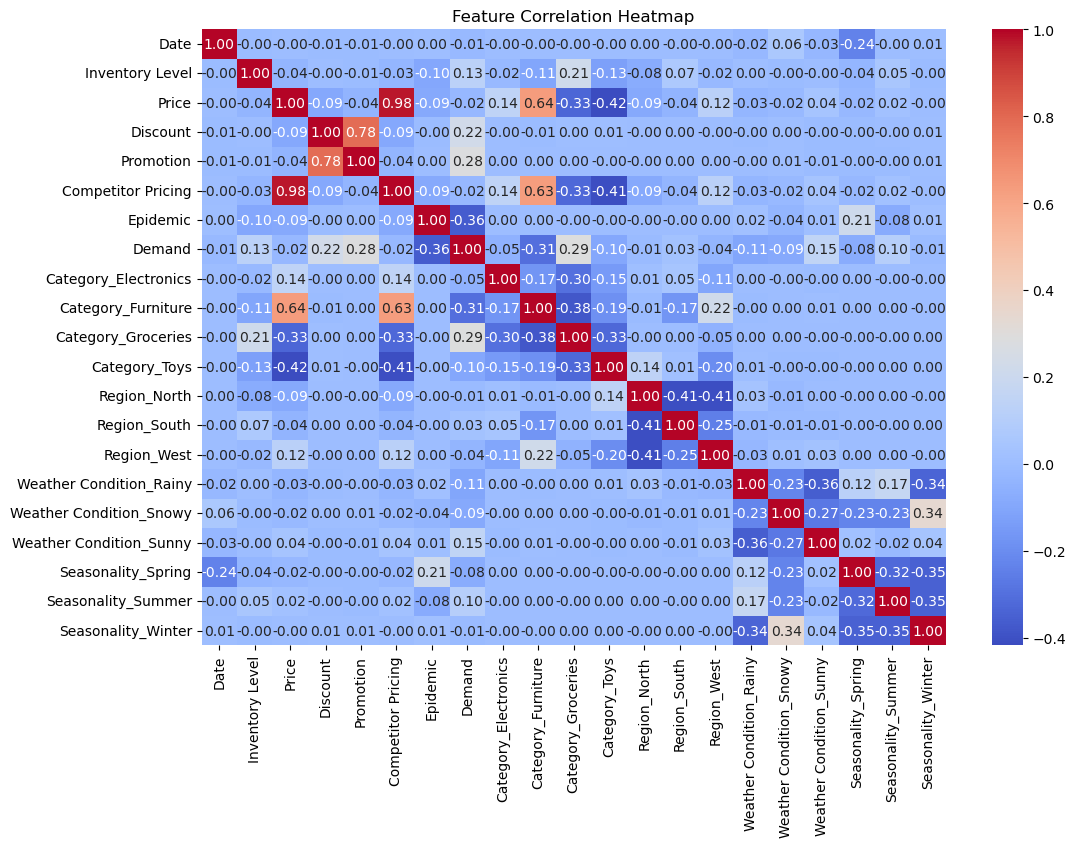

In [33]:
# Correlation Heatmap (Prepared but not shown)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Observations**

Based on the analysis of the correlation matrix and the corresponding heatmap, we can draw the following conclusions:


**Top Positively Correlated Features with Demand:**

| Feature                      | Correlation | Interpretation                                                       |
| ---------------------------- | ----------- | -------------------------------------------------------------------- |
| **Category\_Groceries**      | +0.2896     | When the product is Groceries, Demand tends to be higher.            |
| **Promotion**                | +0.2825     | Promotion **increases demand** significantly — logical in retail.    |
| **Discount**                 | +0.2247     | Higher discounts associate with higher demand — expected effect.     |
| **Weather Condition\_Sunny** | +0.1521     | Demand slightly higher on sunny days — minor positive effect.        |
| **Inventory Level**          | +0.1266     | More stock means potential for higher demand — though low influence. |
| **Seasonality\_Summer**      | +0.1027     | Slightly higher demand in summer — depends on product type.          |

**Top Negatively Correlated Features with Demand:**

| Feature                      | Correlation | Interpretation                                                              |
| ---------------------------- | ----------- | --------------------------------------------------------------------------- |
| **Epidemic**                 | **-0.3637** | Strongest negative effect — demand **drops during epidemic periods**.       |
| **Category\_Furniture**      | **-0.3066** | Furniture items tend to have **lower demand compared to other categories**. |
| **Weather Condition\_Rainy** | -0.1073     | Slight demand reduction on rainy days.                                      |
| **Category\_Toys**           | -0.1006     | Toys see lower demand in this dataset context.                              |
| **Seasonality\_Spring**      | -0.0796     | Slightly lower demand during spring season.                                 |
| **Region\_West**             | -0.0392     | Slightly lower demand in Western region.                                    |


We will now focus on analyzing the relationship between features that show positive correlation with demand.

#### 4.3 Distribution of Demand

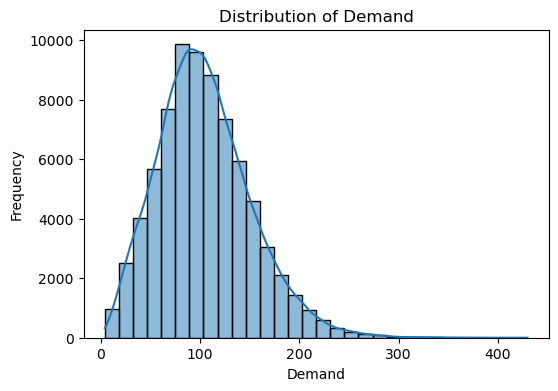

In [38]:
# Distribution of Target Variable 'Demand'
plt.figure(figsize=(6,4))
sns.histplot(sales_df['Demand'], kde=True, bins=30)
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

**<u>Observations</u>:**
- The histogram of Demand shows a right-skewed distribution. There are few outliners causing long right-skewed distribution.
- Most demand values are concentrated between 50 and 150 units.
- Mode of the distribution is around 90 to 100. 

#### 4.4 Demand by Seasonality

To explore the correlation between **Winter Season** and **Demand**, we create a boxplot for visual analysis

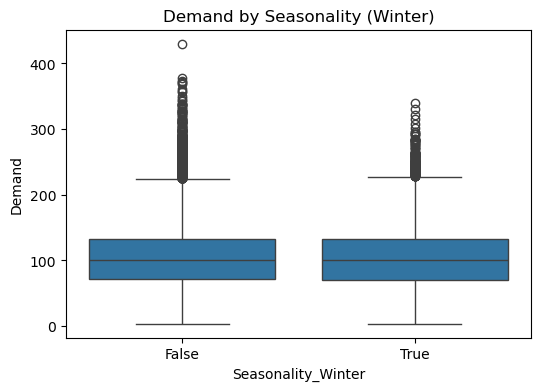

In [41]:
# Boxplot: Demand by Seasonality
if 'Seasonality_Winter' in sales_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Seasonality_Winter', y='Demand', data=sales_df)
    plt.title('Demand by Seasonality (Winter)')
    plt.show()

To explore the correlation between Summar Season and Demand, we create a boxplot for visual analysis

**<u>Observation for Seasonality_Winter</u>:**

- **False** = Non-Winter Season and **True** = Winter Season.
- Both box plot show similar median demand , around 100. and the spread (25th to 75th percentile) is similar for both groups.
- This suggests that, on average demand remains almost the same wheather it is winter or not.
- Both groups have a significant number of high outliers.(above 200) and are similar. This suggest high demands are also not depends on the winter season.
- **Conclusion** : Seasonality (Winter) does not have a strong influence on product demand based on this boxplot.
- We should check other features like **price** , **promption** or **inventory level**. 

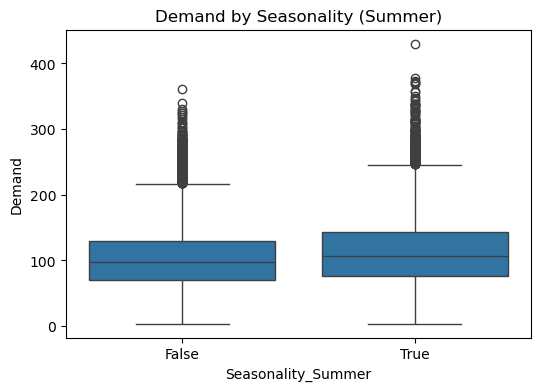

In [44]:
if 'Seasonality_Summer' in sales_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Seasonality_Summer', y='Demand', data=sales_df)
    plt.title('Demand by Seasonality (Summer)')
    plt.show()

**<u>Observation for Seasonality_Summer</u>:**

- **False** = Non-Summer and **True** = Summer.
- Plot suggests a modest increase in typical demand during summer.
- For both the interquartile Range is similar.
- Outlier are present in both groups, but they are slightly more during summer.
- As the demand is slightly higher in Summer, it could be statistically significant. 


#### 4.5 Relationship between price and Demand

To explore the correlation between Price and Demand, we create a scatterplot for visual analysis

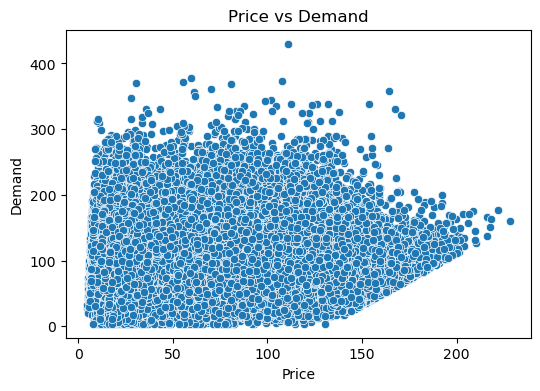

In [47]:
# Relationship between Price and Demand
plt.figure(figsize=(6,4))
sns.scatterplot(x='Price', y='Demand', data=sales_df)
plt.title('Price vs Demand')
plt.xlabel('Price')
plt.ylabel('Demand')
plt.show()

#### 4.5 Relationship between price and Demand

**<u>Observation</u>:**

- The plot shows as the price is increased the demand tends to decrease.
- **Heteroscedasticity:** The spread of demand varies across price levels - there is wider range of demand at lower prices and a narrower range at higher prices.
- So the plot does not show very linear relationship between Price and Demand.
- This is non-constant varaince, which is important for linear regression.

#### 4.6 Relationship between Discount and Demand

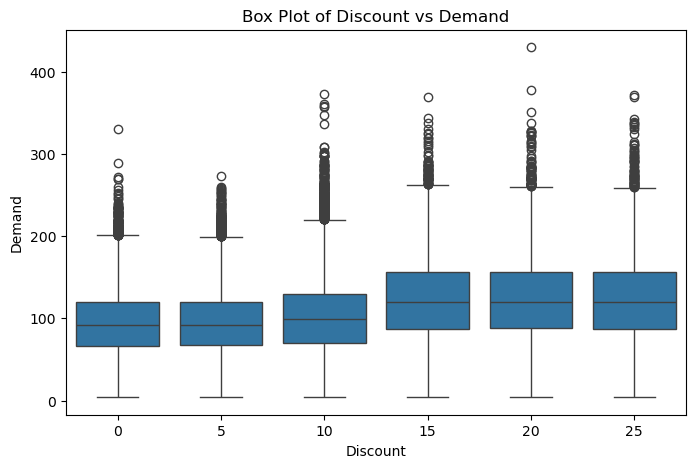

In [51]:
# Relationship between Discount and Demand
plt.figure(figsize=(8,5))
sns.boxplot(x='Discount', y='Demand', data=sales_df)
plt.title('Box Plot of Discount vs Demand')
plt.xlabel('Discount')
plt.ylabel('Demand')
plt.show()

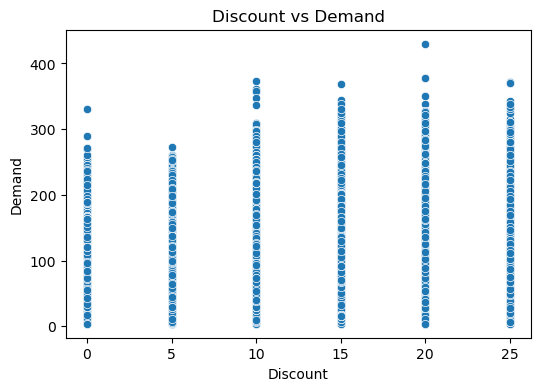

In [52]:
# Relationship between Discount and Demand
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Demand', data=sales_df)
plt.title('Discount vs Demand')
plt.xlabel('Discount')
plt.ylabel('Demand')
plt.show()

**<u>Observation</u>:**
- The discount variables has discrete values - 0,5,10,15,20,25. Each indicating the discount percentage.
- There is upward shift in the maximum demand as discounts increase.
- Higher discounts seems to be associated with more frequent high-demand outcomes.
- At every discount level, the demand shows large variability from 0 to 300 plus. **This implies that discount alone does not fully explain the demand**. There could be other variables influencing demand.

#### 4.7 Relationship between Promotion and Demand

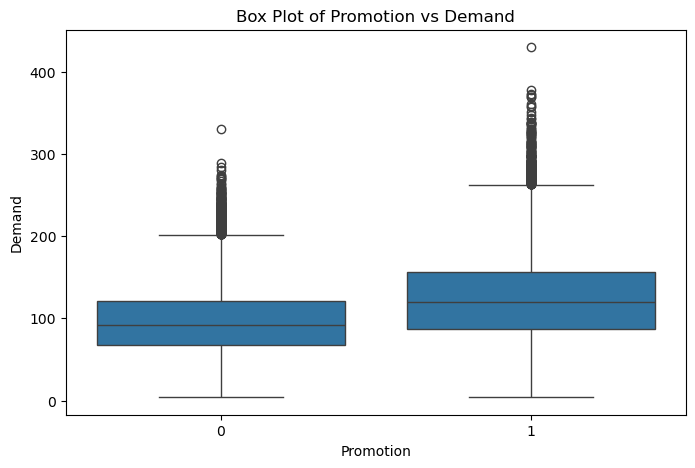

In [55]:
# Relationship between Discount and Demand
plt.figure(figsize=(8,5))
sns.boxplot(x='Promotion', y='Demand', data=sales_df)
plt.title('Box Plot of Promotion vs Demand')
plt.xlabel('Promotion')
plt.ylabel('Demand')
plt.show()

**<u>Observation</u>:**

- **0** = No promotion and **1** = Promotion
- The median demand is higher when promotion is applied. This indicates the promotions tend to increase typical demand
- The interquartile range is wide for promotion group.  suggesting more variability in demand when promotions are active.
- Also promoted group has greater outliers, showing higher potential peak demands during promotions.

#### 4.8 Region distribution

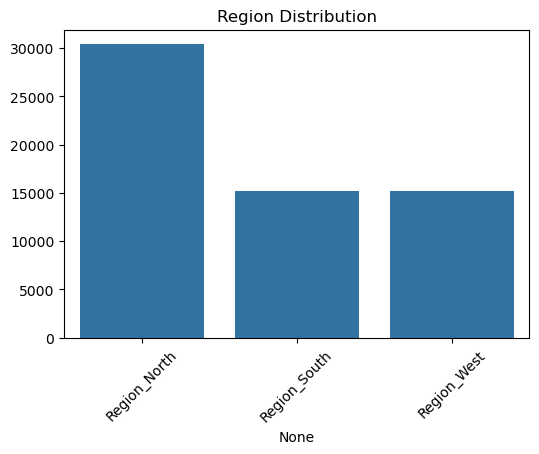

In [58]:
# Countplot: Region Distribution (if region dummies exist)
region_cols = [col for col in sales_df.columns if 'Region_' in col]
if region_cols:
    region_counts = sales_df[region_cols].sum()
    plt.figure(figsize=(6,4))
    sns.barplot(x=region_counts.index, y=region_counts.values)
    plt.title('Region Distribution')
    plt.xticks(rotation=45)
    plt.show()

**<u>Observation:</u>**

- Region North dominates the recorded observations.(30,000)
- Region South and North are balanced.(15,000 each)
- If we are condering Region to build the model with this dataset. Then the results could be biased as Region_North has more observations.
- The plot suggests the Region North is a large market area, may be capital city.  This can be used for business strategy.

#### 4.9 Time Series Plot: Demand over Time 


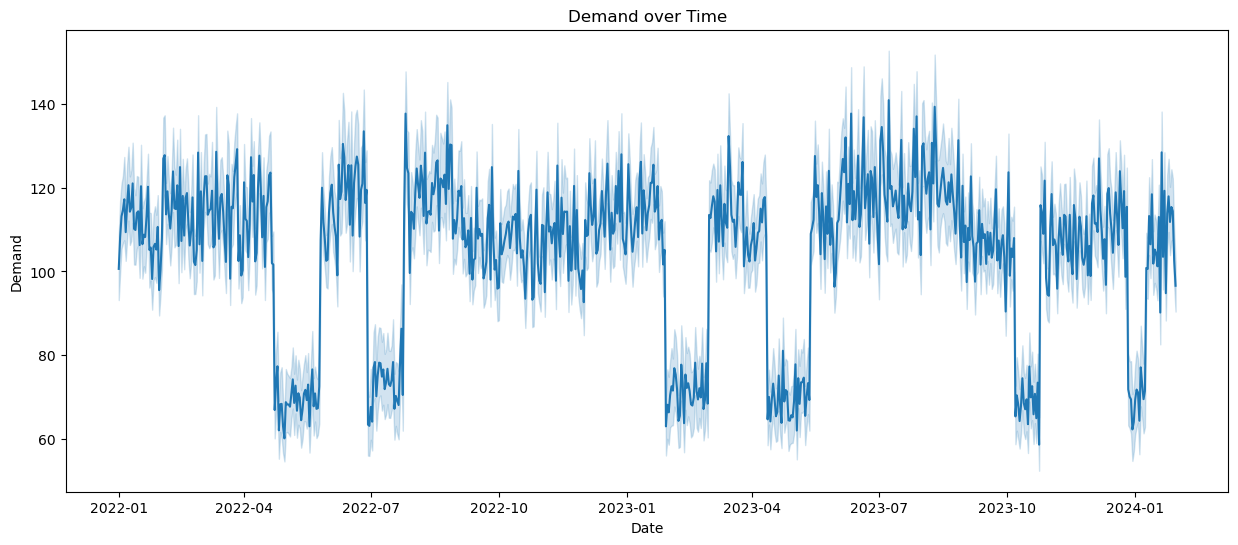

In [61]:
if 'Date' in sales_df.columns:
    plt.figure(figsize=(15,6))
    sns.lineplot(x='Date', y='Demand', data=sales_df)
    plt.title('Demand over Time')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.show()

**<u>Observation:</u>**

- There is unclear long-term upward or downward trend in the demand over the entire period.
- However, the plot shows periodicity. i.e, There are **high demand periods** and **low demand periods**.
- The high demand periods are around **July-August** months. The demands are between 110 to 140.
- There are few low demand periods Jan-Feb 2023 and 2024. and also around Apr-May 2022 and 2023. The demands are between 60 and 80.
- This shows predictible yearly cycle in demand.
- In summary, the plot illustrates a demand pattern driven primarily by strong yearly seasonality, with demand consistently higher in the mid-year months and lower at the beginning of the year and late spring/early summer. There are also smaller, higher-frequency variations throughout the year.

## 5.Model Selection

In this section, we focus on selecting and evaluating suitable machine learning algorithms to predict the target variable based on the insights gathered during Exploratory Data Analysis (EDA). Two different models are tested to compare their effectiveness: 1) Ordinary Least Squares (OLS) Regression (Baseline) and 2) XGBoost (Optimized for Imbalanced Data)

Lets start the OLS model first using python statsmodels library.

#### 5.1 OLS Regressioin with Statsmodels.

Lets first use the **Ordinary Least Square** OLS model to fit the linear regression model and check the Model performance and p-values for each feature. OLS is used as the baseline model due to its simplicity and interpretability. It assumes a linear relationship between the independent variables and the target variable (Demand).

In [66]:
import statsmodels.api as sm
import numpy as np

# Define features and target
X = sales_df.drop(['Demand','Date'], axis=1)
y = sales_df['Demand']
X.dtypes   

Inventory Level              int64
Price                      float64
Discount                     int64
Promotion                    int64
Competitor Pricing         float64
Epidemic                     int64
Category_Electronics          bool
Category_Furniture            bool
Category_Groceries            bool
Category_Toys                 bool
Region_North                  bool
Region_South                  bool
Region_West                   bool
Weather Condition_Rainy       bool
Weather Condition_Snowy       bool
Weather Condition_Sunny       bool
Seasonality_Spring            bool
Seasonality_Summer            bool
Seasonality_Winter            bool
dtype: object

In [67]:
# We need to convert all the bool values to 0 and 1.
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
X.dtypes

Inventory Level              int64
Price                      float64
Discount                     int64
Promotion                    int64
Competitor Pricing         float64
Epidemic                     int64
Category_Electronics         int32
Category_Furniture           int32
Category_Groceries           int32
Category_Toys                int32
Region_North                 int32
Region_South                 int32
Region_West                  int32
Weather Condition_Rainy      int32
Weather Condition_Snowy      int32
Weather Condition_Sunny      int32
Seasonality_Spring           int32
Seasonality_Summer           int32
Seasonality_Winter           int32
dtype: object

In [68]:
# Add constant (intercept term)
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Summary to view p-values
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Demand   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     3167.
Date:                Sat, 21 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:43:09   Log-Likelihood:            -3.7823e+05
No. Observations:               76000   AIC:                         7.565e+05
Df Residuals:                   75980   BIC:                         7.567e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      76.4505      0.720    106.229      0.000      75.040      77.861
Inventory Level             0.0036      0.001      6.103      0.000       0.002       0.005
Price                       0.3265      0.015     21.256      0.000       0.296       0.357
Discount                    0.3005      0.028     10.846      0.000       0.246       0.355
Promotion                  26.0775      0.438     59.600      0.000      25.220      26.935
Competitor Pricing          0.0723      0.014      4.990      0.000       0.044       0.101
Epidemic                  -39.0216      0.332   -117.592      0.000     -39.672     -38.371
Category_Electronics      -19.7197      0.497    -39.712      0.000     -20.693     -18.746
Category_Furniture        -60.0764      0.518   -116.061      0.000     -61.091     -59.062
Category_Groceries         15.7939      0.400     39.511      0.000      15.010      16.577
Category_Toys              -2.0695      0.537     -3.855      0.000      -3.122      -1.017
Region_North                1.7980      0.352      5.113      0.000       1.109       2.487
Region_South               -2.9552      0.407     -7.262      0.000      -3.753      -2.158
Region_West                 1.8587      0.421      4.419      0.000       1.034       2.683
Weather Condition_Rainy    -9.3475      0.360    -25.980      0.000     -10.053      -8.642
Weather Condition_Snowy    -9.5909      0.431    -22.259      0.000     -10.435      -8.746
Weather Condition_Sunny     9.8761      0.323     30.540      0.000       9.242      10.510
Seasonality_Spring          2.5389      0.386      6.579      0.000       1.783       3.295
Seasonality_Summer          8.9628      0.378     23.682      0.000       8.221       9.705
Seasonality_Winter          2.1509      0.370      5.813      0.000       1.426       2.876
==============================================================================
Omnibus:                     2826.992   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4573.596
Skew:                           0.338   Prob(JB):                         0.00
Kurtosis:                       3.994   Cond. No.                     2.82e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.82e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**OLS Train-test split and RMSE**

In [70]:
from sklearn.metrics import mean_squared_error, r2_score  ## These functions will be used to evalue the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ols_model = sm.OLS(y_train, X_train).fit()

# Predict on test data
y_pred_ols = ols_model.predict(X_test)

# Calculate RMSE
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
print(f"OLS RMSE: {rmse_ols:.4f}")

OLS RMSE: 37.3030


**<u>Obeservation</u>:**

- **RMSE** value is 24.57, which is **must higher**, inidcating the predicted values are farther away from the actual true values. 
- R-squared = 0.442 : **Indicates Moderate fit**. This means approximately 44.2% of the variance in 'Demand' can be explained by the independent variables in this model.
- Prob (F-statistic) = 000 : **Indicates the rejection of the null hypothesis**. At least one of independent variables is a **significant predictor of Demand**. This means the model as a whole is statistically significant.
- **P-values** : All the p-values for individual coefficients are 0.00, which means all the independent variables in the model are statistically significant.
- Promotion has the largest positive impact on demand.|
- Seasonality_Summer and Weather Condition_Sunny significantly boost demand.
- Epidemic and Category_Furniture have the largest negative impacts.

**<u>key coefficients</u>:**

|Coefficient|Obesrvations|
|---|---|
|**Inventory Level = 0.0036**|For every one unit increase in Inventory level, Demand increases by 0.0036. This is very **small positive effect.**|
|**Price = 0.3265**|For every one-unit increase in 'Price', 'Demand' is estimated to increase by 0.3265 units, holding other factors constant. This could be rather revers, **The price increase when demand goes high.**. This feature can be ignored.|
|**Discount = 0.3005**| This is as expected as **discounts typically boost demand.**|
|**Promotion = 26.0775**| This shows very strong positive effect.|
|**Competitor Pricing = 0.0723**| This suggests that as competitors raise their prices, your demand slightly increases.|
|**Weather Condition_Sunny = 9.8761**| Higher compared to Rainy and snowy weather conditions.|
|**Seasonality_Summer = 8.9628**| High compared to Winter and Spring. Suggest strong positive seasonal effect.|


#### 5.2 XGBoost (Optimized for Imbalanced Data):

XGBoost, an advanced gradient boosting algorithm, is implemented to handle the complex and potentially non-linear relationships within the data. XGBoost can model feature interactions automatically and is robust to outliers, irrelevant features, and multicollinearity.

In [73]:
from sklearn.model_selection import train_test_split  ## import the train_test_split function to split the dataset into training and testing.
from sklearn.preprocessing import LabelEncoder  ##  LabelEncoder fucntion to convert categorical labels to numberic lables.
from xgboost import XGBRegressor                ##  import XGBoost Regressor
from sklearn.metrics import mean_squared_error, r2_score  ## These functions will be used to evalue the model

xg_sales_df = pd.read_csv('./dataset/sales_data.csv')
## Print the dataset.
xg_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

**Data handling for XGBoost**

In [75]:
# Drop the Dtore ID, Product ID column as they may not help in prediction
# And XGBoost does not support the datetime values so we drop Date column
xg_sales_df.drop(['Date', 'Store ID', 'Product ID'], axis=1, inplace=True)

# Encode Categorical variables
cat_cols = xg_sales_df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    xg_sales_df[col] = le.fit_transform(xg_sales_df[col])
xg_sales_df.dtypes

Category                int32
Region                  int32
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition       int32
Promotion               int64
Competitor Pricing    float64
Seasonality             int32
Epidemic                int64
Demand                  int64
dtype: object

**Define the features and target dataset**

In [77]:
X = xg_sales_df.drop('Demand', axis=1)   ## Features or Predictors in X Matrix
y = xg_sales_df['Demand']                ## Capture the target 'Demand' in y vector.

**Split the dataset**

For training the model, Lets split the sales dataset into two datasets training and testing set. Normally 80% of the dataset is used for Training and 20% of the dataset is for testing.

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
## test_size=0.2 represents ==> 80% training dataset and 20% test dataset.
## random_state=42 ==> Controls the randomness of data, to always get same split of train and test data.

**Initialize XGBoost Regressor**

In [81]:
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=8, 
    random_state=42
)

## Hyperparameter to tune model:
## n_estimators = 100 ---> Number of bossting rounds - The model will build 200 trees, more trees can improve learning.
## learning_rate=0.1 ----> Control learning speed, smaller value makes learning slow but careful
## max_depth=10       ----> Controls model complexity, the depth of the tree. Deeper th trees capture more patterns. 5 is moderate and safe.


**Train XGBoost Model.**

In [83]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

**Test XGBoost Model**

In [85]:
y_pred = xgb_model.predict(X_test)    

**Evaluate Performance**

- **RMSE (Root Mean squared Error)** is a commenly used metric to evaluete the accuracy of an regression model.  It measures the average magnitude of the errors between predicted and actual values. Smaller the RMSE value better the model performance.
 
      
    
- **$R^2$ (R-Squared)** is the coefficient of determination, measures the proportion of the variance in the dependent variable that is explained by the independent variables in the model.

    - $R^2$ = 1.0 is Perfect Model(all variance explained)
    - $R^2$ = 0.0  Model is not doing better the mean calculation.
    - $R^2$ < 0.0 Model is worse than simply predicting the average.
    - $R^2$ --> Higher the $R^2$ Model is better.


In [87]:
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean squared Error - RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Root Mean squared Error - RMSE: 15.7304
R-squared: 0.8880



**<u>Observations</u>**
- $R^2$ = **0.888** is significantly higher than the **OLS model** (R² = 0.44) — indicating that XGBoost explains 86.8% of the variability in demand, a large improvement.

- **RMSE** = **15.73** suggests that the model predicts demand with a low average error — quite good for retail demand data.



---
** Chat-gpt* has been used to generate some part of the code

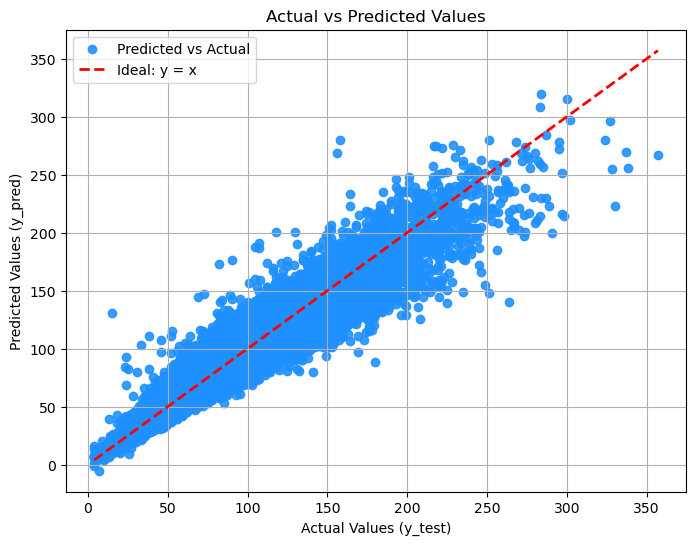

In [89]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.888, color='dodgerblue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal: y = x')

plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

---

## 6.Model Analysis

---



Here is the comparision of OLS vs XGBoost Models, based on above Model selection section.

| Metric                                         | **OLS Regression**                               | **XGBoost Regressor**                                  |
| ---------------------------------------------- | ------------------------------------------------ | ------------------------------------------------------ |
| **RMSE (Root Mean Squared Error)**             | **24.00** (Higher error) | **15.73** (significantly lower)                        |
| **R-squared (R²)**                             | **0.442** (Only 44% variance explained)      | **0.888** (much higher)            |
| **Model Type**                                 | Linear Model (OLS)                           | Ensemble, Non-linear (XGBoost)                         |
| **Handles Non-linearity**                      | ❌ Limited (assumes linearity)                    | ✔️ Captures complex, non-linear relationships          |
| **Sensitive to Outliers**                      | ✔️ Highly sensitive                              | ✔️ Robust to outliers                                  |
| **Handles Feature Interactions Automatically** | ❌ No                                             | ✔️ Yes                                                 |
| **Assumption of Homoscedasticity**             | ✔️ Required                                      | ❌ Not required (tree-based)                            |
| **Performance on High Variance Data**          | Poor (due to heteroscedasticity and outliers)    | Strong (naturally handles variance and complex splits) |

**Key Observations:**
- The OLS model servers as a simple baseline but exhibits clear limitations:
  - $R^2$ = 0.44,  suggests that more than half (55%) of the variability remains unexplained. indicating the OLS model misses **complex relationships** present in the data.
  - OLS assumes a linear relationship between predictors and demands, but from scannet plots we saw non-linearity in most of the cases.
  - We saw there are many outliers in **Demand** this can distort the OLS model.
  - Heteroscedasticity is easily visible from the scatterplots- Violating OLS assumptions.

- XGBoost outperforms OLS:
  - For XGBoost Model, the $R^2$ is 0.888, which indicates model can explain the variability in demand.
  - There are many categirical features, like product category , Region, weather, season etc. XGBoost can handle these with split rules that combine categories example: *if Region = south and Category=Groceries* etc
  - And XGboost is less sensitive to outliers, unlike in OLS the regression line gets shifted.
  - Finally, XGboost is good fit for large dataset with mixed features - categorical and numerical.
    

While OLS Regression provided an interpretable starting point, it fails to model the complex, non-linear nature of retail demand effectively.
XGBoost emerges as the superior model for this problem, offering better predictive accuracy, handling of categorical variables, and resilience to data imperfections such as outliers and heteroscedasticity.




## 7.Conclusion

This project focused on analyzing and forecasting product demand in retail stores using historical sales data. The primary objective was to uncover patterns in past sales and develop predictive models for accurate future demand estimation. The insights gained are intended to facilitate data-driven decision-making, optimize inventory management, and enhance overall store operations.

Accurate demand forecasting is crucial in retail to prevent both overstocking (which leads to storage costs and potential waste) and stockouts (which result in lost sales and reduced customer satisfaction). By improving forecasting, retailers can streamline inventory, minimize these issues, boost operational efficiency, and ultimately increase sales and customer satisfaction.

The project aimed to develop an XGBoost-based predictive regression model for forecasting product demand using historical sales and operational data, with the goal of reducing stockouts and overstocking to ensure efficient inventory management and supply chain operations.

---

## 8.Appendix

---
#### Model Comparison
![Model Comparison](images/model_comparision.png)

#### Code
- Project Code Repository :  https://github.com/JagdishMane/aai-project-retail-store-demand-forecasting.git

#### Dataset 
- Zhenzuo Zhu. (2025). Retail Store Inventory and Demand Forecasting [Data set].
- https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting/data

---

## 9.References

---
- Zhenzuo Zhu. (2025). Retail Store Inventory and Demand Forecasting [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11895299
- OpenAI. (2023). ChatGPT (Mar 14 version) [Large language model]. https://chat.openai.com/chat.
- Chen, T., & Guestrin, C. (n.d.). XGBoost Tutorials. XGBoost Documentation. https://xgboost.readthedocs.io/en/stable/tutorials/index.html
- Agresti, A., & Kateri, M. (2021). Foundations of statistics for data scientists: With R and Python. CRC Press. https://doi.org/10.1201/9781003144328

---